Delhi climate change time -sereis analysis


In [54]:
# imporing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [55]:
df = pd.read_csv('/content/DailyDelhiClimateTrain.csv') # creating the dataframe

In [56]:
# simple analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [57]:
df.isna().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [58]:
df.dtypes

,0
date,object
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df = df[['date','meantemp']]

In [61]:
df['date'] = df['date'].astype('datetime64[ns]')

In [62]:
df = df.sort_values(by='date')

In [63]:
df.set_index('date',inplace=True)

In [64]:
# visualisation of data
import plotly.express as px

px.line(df,x=df.index,y='meantemp')


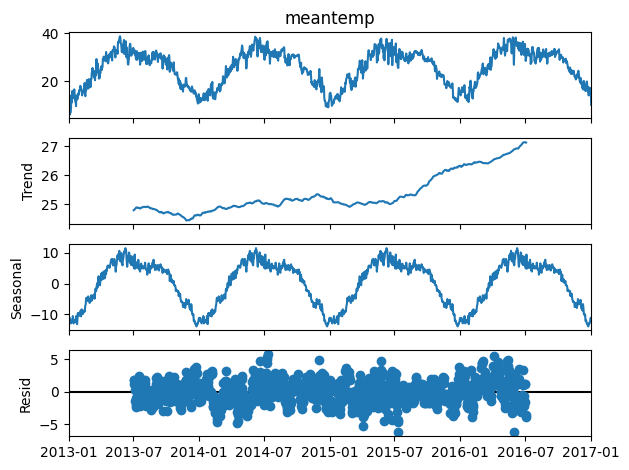

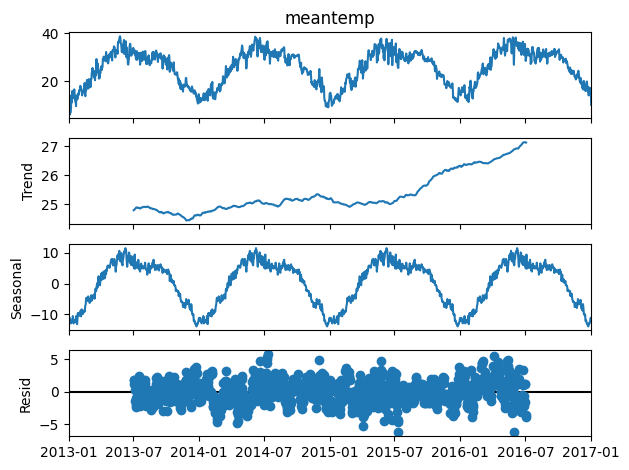

In [65]:
# quick decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(df['meantemp'], period=365)
decompose.plot()

In [66]:
# stationary tests
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(df['meantemp'])

print('pvalue',adf_test[1])

for key , value in adf_test[4].items():
  print(f'{key} : {value}')

# since p value > critical value thus we can say that we fail to reject the null hypothesis that is our data is non -stationary
# and it has unit root

pvalue 0.2774121372301602
1% : -3.4348647527922824
5% : -2.863533960720434
10% : -2.567831568508802


In [67]:
# kpss test
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(df['meantemp'])

print('pvalue',kpss_test[1])

for key , value in kpss_test[3].items():
  print(f'{key} : {value}')

pvalue 0.1
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


In [68]:
df['first_diff'] = df['meantemp'].diff()

In [69]:
df.dropna(inplace=True)

In [70]:
kpss_test = kpss(df['first_diff'])

print('pvalue',kpss_test[1])

for key , value in kpss_test[3].items():
  print(f'{key} : {value}')

pvalue 0.1
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739


In [71]:
adf_test = adfuller(df['first_diff'])

print('pvalue',adf_test[1])

for key , value in adf_test[4].items():
  print(f'{key} : {value}')

# finally stationary data thus no unit root

pvalue 2.764863137594565e-29
1% : -3.4348647527922824
5% : -2.863533960720434
10% : -2.567831568508802


we had trend - stationarity

In [72]:
px.line(df,x=df.index,y='first_diff')

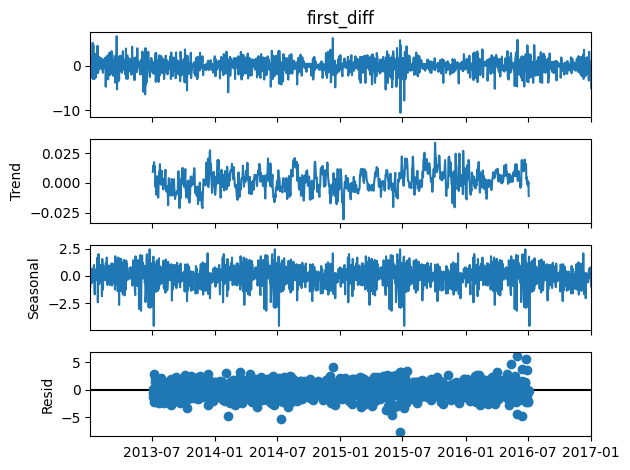

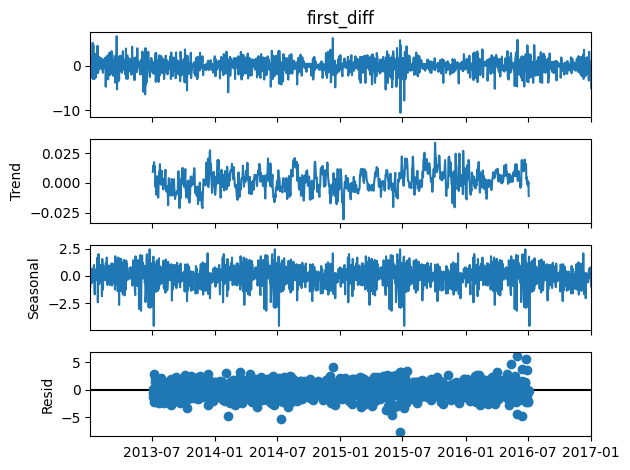

In [73]:
# after differencing quick decomposition

decompose = seasonal_decompose(df['first_diff'], period=365)
decompose.plot()

In [76]:
# detranding using linear
from  scipy.signal import detrend
import plotly.express as px

df['detrend'] = detrend(df['meantemp'],type='linear')
px.line(df, x=df.index, y='detrend')

In [77]:
print('kpss test for detrend series')
kpss_test = kpss(df['detrend'])

print('pvalue',kpss_test[1])

for key , value in kpss_test[3].items():
  print(f'{key} : {value}')

print('adf test for detrend series ')
adf_test = adfuller(df['detrend'])

print('pvalue',adf_test[1])

for key , value in adf_test[4].items():
  print(f'{key} : {value}')

# detrending did'nt perform well as here is still we have the trend-stationarity

kpss test for detrend series
pvalue 0.1
10% : 0.347
5% : 0.463
2.5% : 0.574
1% : 0.739
adf test for detrend series 
pvalue 0.3649794890712391
1% : -3.4348678719530934
5% : -2.863535337271721
10% : -2.5678323015457787


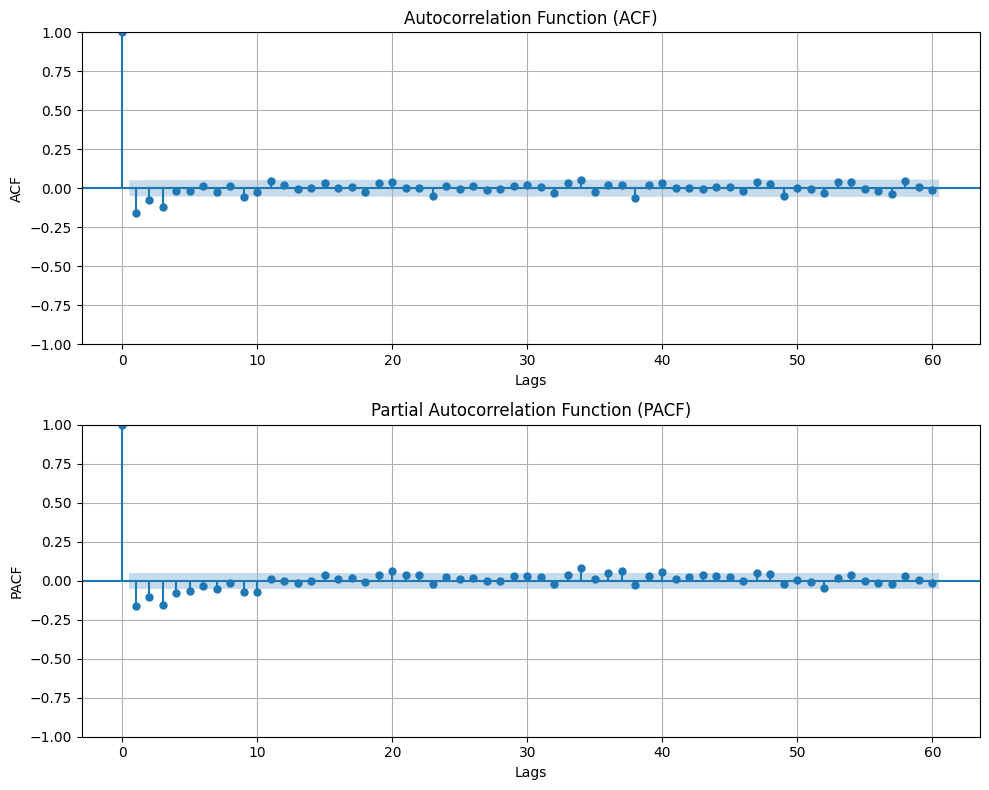

In [91]:
# acf , pcf plots
from statsmodels.tsa.stattools import pacf , acf
from statsmodels.graphics.tsaplots import plot_pacf , plot_acf
import matplotlib.pyplot as plt

fig , ax = plt.subplots(2,1,figsize=(10, 8))

plot_acf(df['first_diff'], lags=60, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')
ax[0].set_xlabel('Lags')
ax[0].set_ylabel('ACF')
ax[0].grid(True)

plot_pacf(df['first_diff'], lags=60, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF)')
ax[1].set_xlabel('Lags')
ax[1].set_ylabel('PACF')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [99]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

p = q = range(0, 4)
pq = itertools.product(p, q)

best_aic = float("inf")
best_order = None

print("Searching for best ARIMA model (d=0 for differenced data):")
for param_p, param_q in pq:
    try:
        # Using d=0 since 'first_diff' is already differenced
        mod = ARIMA(df['first_diff'], order=(param_p, 0, param_q))
        results = mod.fit()
        current_aic = results.aic
        print(f'ARIMA({param_p},0,{param_q}) - AIC:{current_aic:.2f}')

        if current_aic < best_aic:
            best_aic = current_aic
            best_order = (param_p, 0, param_q)

    except Exception as e:
        continue

print(f"\nBest ARIMA model for 'first_diff': ARIMA{best_order} with AIC: {best_aic:.2f}")


Searching for best ARIMA model (d=0 for differenced data):
ARIMA(0,0,0) - AIC:5650.18
ARIMA(0,0,1) - AIC:5602.11
ARIMA(0,0,2) - AIC:5573.72
ARIMA(0,0,3) - AIC:5542.49
ARIMA(1,0,0) - AIC:5614.07
ARIMA(1,0,1) - AIC:5544.46
ARIMA(1,0,2) - AIC:5546.17
ARIMA(1,0,3) - AIC:5542.22
ARIMA(2,0,0) - AIC:5600.85
ARIMA(2,0,1) - AIC:5546.10
ARIMA(2,0,2) - AIC:5546.31
ARIMA(2,0,3) - AIC:5544.02
ARIMA(3,0,0) - AIC:5566.34
ARIMA(3,0,1) - AIC:5543.03
ARIMA(3,0,2) - AIC:5543.75
ARIMA(3,0,3) - AIC:5545.66

Best ARIMA model for 'first_diff': ARIMA(1, 0, 3) with AIC: 5542.22


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

p = d = q = range(0, 3) # Non-seasonal p, d, q (d will be set to 1 explicitly)
P = D = Q = range(0, 2) # Seasonal P, D, Q (D will be set to 1 explicitly)
s = 365 # Seasonal period (yearly for daily data)

pdq = list(itertools.product(p, [1], q))
seasonal_pdq = list(itertools.product(P, [1], Q, [s]))

best_aic = float("inf")
best_order = None
best_seasonal_order = None

print("Searching for best SARIMA model:")

for param_non_seasonal in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            # Fit SARIMAX model to the original 'meantemp' series
            mod = SARIMAX(df['meantemp'],
                          order=param_non_seasonal,
                          seasonal_order=param_seasonal,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
            results = mod.fit(disp=False)
            current_aic = results.aic

            print(f'SARIMA{param_non_seasonal}{param_seasonal} - AIC:{current_aic:.2f}')

            # Update best model if current AIC is lower
            if current_aic < best_aic:
                best_aic = current_aic
                best_order = param_non_seasonal
                best_seasonal_order = param_seasonal

        except Exception as e:
            continue

print(f"\nBest SARIMA model for 'meantemp': SARIMA{best_order}{best_seasonal_order} with AIC: {best_aic:.2f}")


Searching for best SARIMA model:


XGBoost RMSE: 1.81


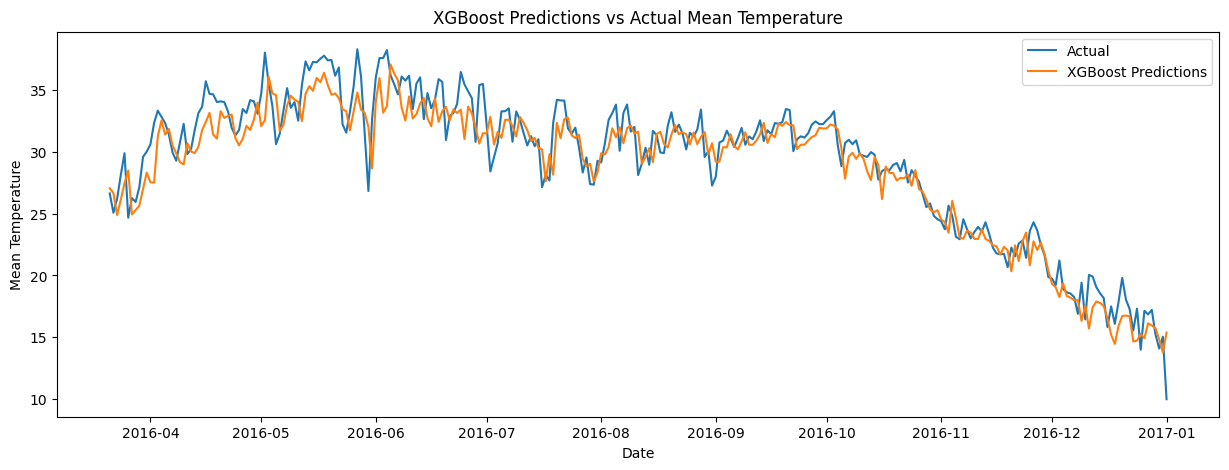

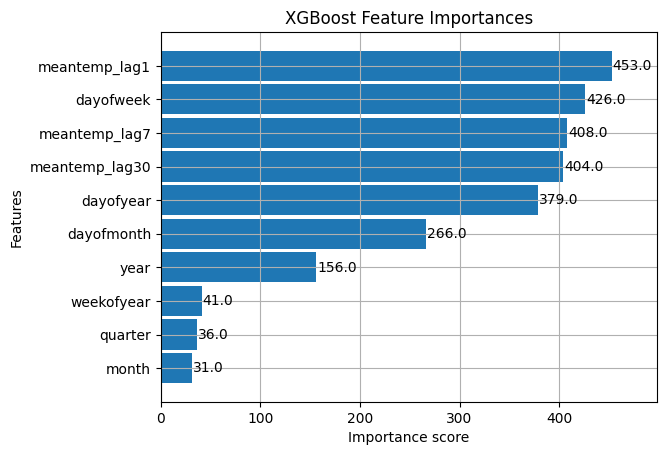

In [97]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Create features for XGBoost
def create_features(df, label=None):
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week.astype(int)

    # Lagged features
    df['meantemp_lag1'] = df['meantemp'].shift(1)
    df['meantemp_lag7'] = df['meantemp'].shift(7) # Weekly lag
    df['meantemp_lag30'] = df['meantemp'].shift(30) # Monthly lag

    if label:
        df['label'] = df[label]
    return df

df_xgb = df.copy()
df_xgb = create_features(df_xgb, label='meantemp')

# Drop rows with NaN values created by lagging
df_xgb.dropna(inplace=True)

# Define features (X) and target (y)
FEATURES = ['dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'dayofmonth', 'weekofyear',
            'meantemp_lag1', 'meantemp_lag7', 'meantemp_lag30']
TARGET = 'meantemp'

X = df_xgb[FEATURES]
y = df_xgb[TARGET]

# Split data into training and testing chronologically
train_size = int(len(df_xgb) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Initialize and train XGBoost Regressor
reg = xgb.XGBRegressor(n_estimators=150,
                       early_stopping_rounds=50,
                       eval_metric='rmse',
                       objective='reg:squarederror',
                       n_jobs=-1)

reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False)

# Make predictions
y_pred = reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'XGBoost RMSE: {rmse:.2f}')

# Plotting predictions vs actual
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='XGBoost Predictions')
plt.title('XGBoost Predictions vs Actual Mean Temperature')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.legend()
plt.show()

# Feature importance
_ = xgb.plot_importance(reg, height=0.9, max_num_features=10)
plt.title('XGBoost Feature Importances')
plt.show()

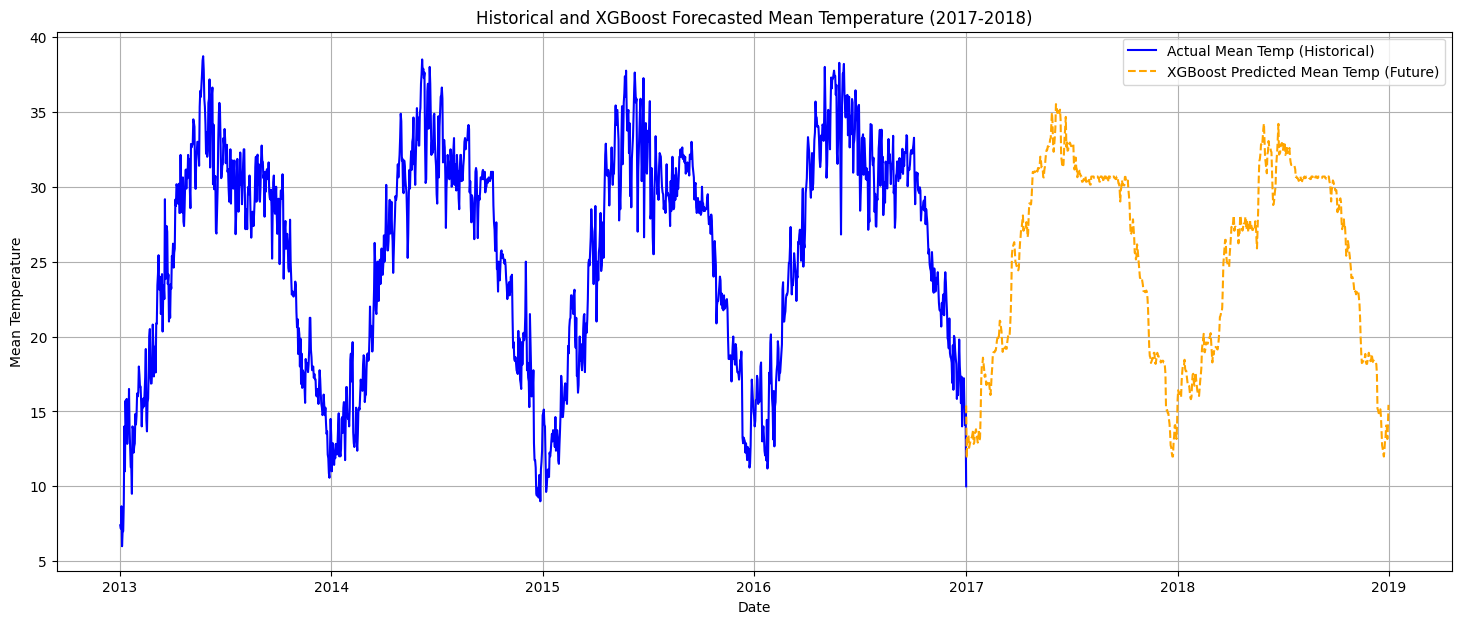

In [101]:
# making prediction for one year from 2017 to 2018

future_dates = pd.date_range(start='2017-01-01', end='2018-12-31', freq='D')
future_df = pd.DataFrame(index=future_dates)

future_df['dayofweek'] = future_df.index.dayofweek
future_df['quarter'] = future_df.index.quarter
future_df['month'] = future_df.index.month
future_df['year'] = future_df.index.year
future_df['dayofyear'] = future_df.index.dayofyear
future_df['dayofmonth'] = future_df.index.day
future_df['weekofyear'] = future_df.index.isocalendar().week.astype(int)

future_df['meantemp'] = np.nan
future_df['meantemp_lag1'] = np.nan
future_df['meantemp_lag7'] = np.nan
future_df['meantemp_lag30'] = np.nan

# Prepare initial historical data for lags.
# Using df directly which is available in the kernel state and contains 'meantemp'.
historical_meantemp = df['meantemp']

for i in range(len(future_df)):
    current_date = future_df.index[i]

    lag1_date = current_date - pd.Timedelta(days=1)
    lag7_date = current_date - pd.Timedelta(days=7)
    lag30_date = current_date - pd.Timedelta(days=30)

    if lag1_date in historical_meantemp.index:
        future_df.loc[current_date, 'meantemp_lag1'] = historical_meantemp.loc[lag1_date]
    elif lag1_date in future_df.index:
        future_df.loc[current_date, 'meantemp_lag1'] = future_df.loc[lag1_date, 'meantemp']

    # Get meantemp_lag7
    if lag7_date in historical_meantemp.index:
        future_df.loc[current_date, 'meantemp_lag7'] = historical_meantemp.loc[lag7_date]
    elif lag7_date in future_df.index:
        future_df.loc[current_date, 'meantemp_lag7'] = future_df.loc[lag7_date, 'meantemp']

    # Get meantemp_lag30
    if lag30_date in historical_meantemp.index:
        future_df.loc[current_date, 'meantemp_lag30'] = historical_meantemp.loc[lag30_date]
    elif lag30_date in future_df.index:
        future_df.loc[current_date, 'meantemp_lag30'] = future_df.loc[lag30_date, 'meantemp']

    # Ensure all required features are present for prediction
    X_current = future_df.loc[current_date, FEATURES].to_frame().T

    # Make prediction
    future_df.loc[current_date, 'meantemp'] = reg.predict(X_current)[0]

# Plotting the results
combined_df_to_plot = pd.concat([df['meantemp'], future_df['meantemp']])

plt.figure(figsize=(18, 7))
plt.plot(df['meantemp'].index, df['meantemp'], label='Actual Mean Temp (Historical)', color='blue')
plt.plot(future_df.index, future_df['meantemp'], label='XGBoost Predicted Mean Temp (Future)', color='orange', linestyle='--')

plt.title('Historical and XGBoost Forecasted Mean Temperature (2017-2018)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.legend()
plt.grid(True)
plt.show()